In [1]:
from wincdl.utils.utils_outliers import add_outliers_2d
import matplotlib.pyplot as plt
import numpy as np
import torch

data = np.load("text_4_5000_ICML.npz")

X = data["X"]
D = data["D"]

X = X[None, None, ...]

In [2]:
X.shape

(1, 1, 2321, 2000)

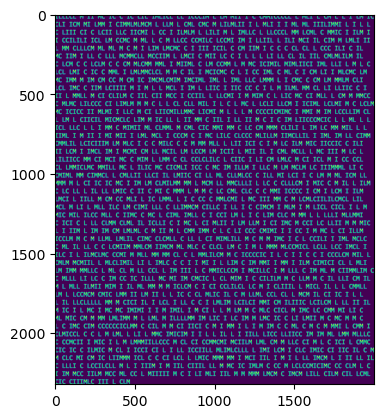

In [3]:
plt.imshow(X[0, 0, ...])

In [28]:
X_outliers, mask = add_outliers_2d(X, 0.2, strength=3, seed=None, patch_size=(50, 50))

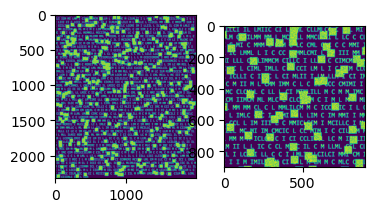

In [29]:
s1 = 990
s2 = 550
t1 = s1 + 900
t2 = s2 + 900
X_zooom = X_outliers[:, :, s1:t1, s2:t2]
mask_zoom = mask[:, :, s1:t1, s2:t2]
fig, axes = plt.subplots(1, 2, figsize=(4, 3))
axes[0].imshow(X_outliers[0, 0])
axes[1].imshow(X_zooom[0, 0])

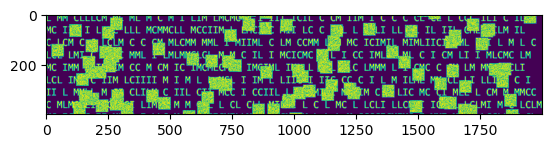

In [30]:
plt.imshow(X_outliers[0, 0, 200:600, :2800])

In [31]:
true_alpha = mask_zoom.sum() / mask_zoom.numel()
X_zooom.shape, true_alpha

(torch.Size([1, 1, 900, 900]), tensor(0.1582))

In [32]:
full_alpha = mask.sum() / mask.numel()
full_alpha

tensor(0.1800)

In [33]:
from wincdl.wincdl import WinCDL
from wincdl.utils.utils_exp import evaluate_D_hat
from wincdl.loss import OutlierLoss
import time

seed = torch.randint(0, 2**10, (1,)).item()


wincdl_params = {
    "n_components": 6,
    "kernel_size": (35, 30),
    "n_channels": 1,
    "lmbd": 0.1,
    "scale_lmbd": True,
    "epochs": 30,
    "max_batch": 5,
    "mini_batch_size": 10,
    "sample_window": (500, 500),
    "optimizer": "adam",
    "n_iterations": 60,
    "window": False,
    "device": "cuda",
    "random_state": seed,
    "positive_D": True,
    "outliers_kwargs": dict(method="mad", alpha=3.5)
}

# Setup the callback for monitoring and visualization
results2 = []
t_start = time.perf_counter()

def callback_fn(model, epoch, loss):
    global t_start
    runtime = time.perf_counter() - t_start
    score = evaluate_D_hat(np.expand_dims(D, axis=1), model.D_hat_)
    # from alphacsc.utils.dictionary import tukey_window

    # fig, ax = plt.subplots(1, model.D_hat_.shape[0], figsize=(12, 7))
    # for i in range(model.D_hat_.shape[0]):
    #     ax[i].imshow(model.D_hat_[i, 0, :, :]*tukey_window(model.D_hat_.shape[2], model.D_hat_.shape[3]))
    # plt.show()

    # copy = X_zooom.clone()
    # xh, zh = wincdl2.csc(torch.tensor(copy).to(wincdl2.device))
    # mask_outliers = model.loss_fn.get_outliers_mask(xh, zh, X_zooom)
    # plt.imshow(mask_outliers[0, 0].detach().cpu().numpy())

    if epoch % 5 == 0:
        if isinstance(model.loss_fn, OutlierLoss):
            print(model.loss_fn.method, model.loss_fn._threshold, score)
        else:
            print(score)

    results2.append(
        {
            "epoch": epoch,
            "loss": loss,
            "time": runtime,
            "score": score,
        }
    )
    t_start = time.perf_counter()

In [34]:
np.unique(X, return_counts=True)

(array([0., 1.], dtype=float32), array([4002633,  639367]))

In [35]:
from wincdl.utils.utils_outlier_comparison import remove_outliers_before_cdl

zshape = (
    X_outliers.shape[0],
    X_outliers.shape[1],
    X_outliers.shape[-2] - wincdl_params["kernel_size"][0] + 1,
    X_outliers.shape[-1] - wincdl_params["kernel_size"][1] + 1,
)

X_before, mask_before = remove_outliers_before_cdl(
    data=X_outliers,
    activation_vector_shape=zshape,
    method="quantile",
    alpha=full_alpha.item(),
    moving_average=None,
    opening_window=True,
    union_channels=False,
    return_outliers_mask=True,
    )

threshold = torch.quantile(X_outliers, 1-(full_alpha.item())).item()
threshold

1.0

In [36]:
X_thresh = X_outliers.clone()
mask_thresh = X_thresh > threshold
X_thresh[mask_thresh] = X_thresh[~mask_thresh].mean()

In [37]:
X_thresh.shape

torch.Size([1, 1, 2321, 2000])

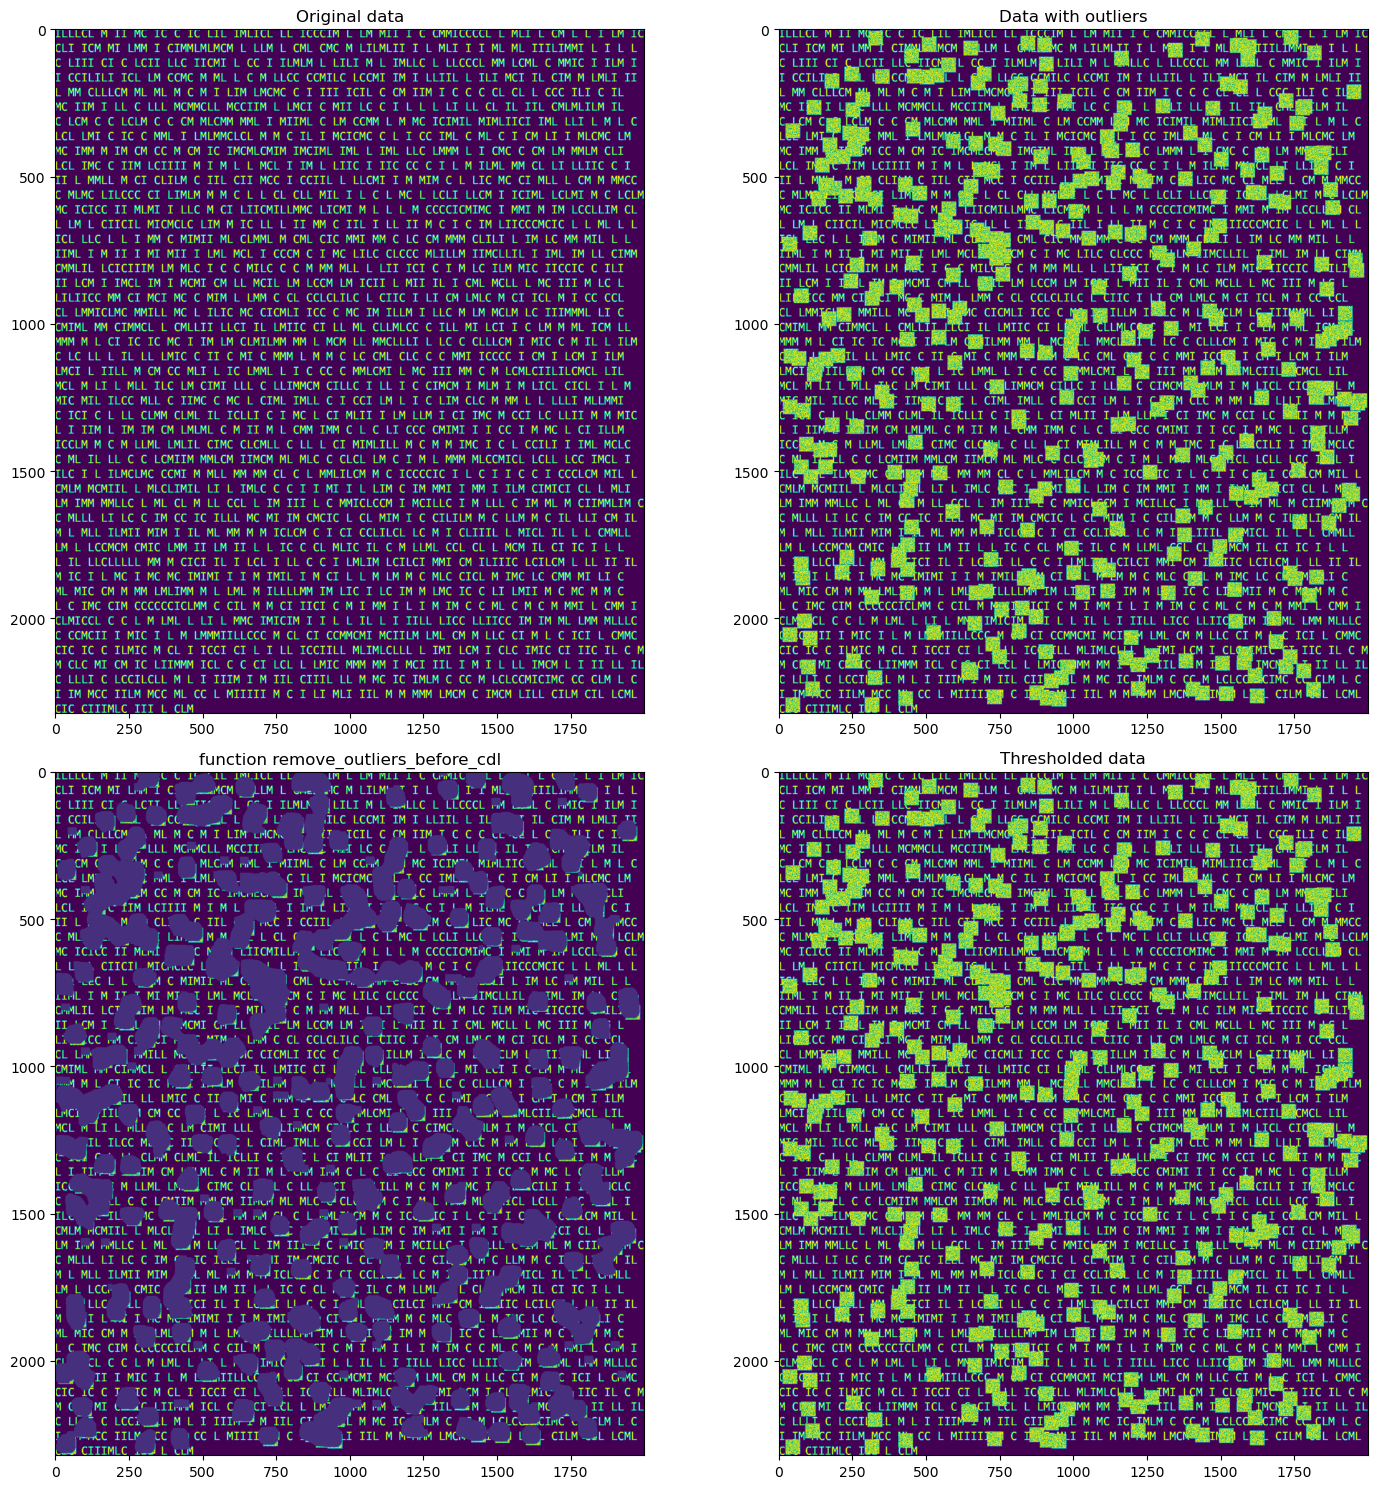

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

axes[0,0].imshow(X[0, 0])
axes[0,0].set_title("Original data")

axes[0,1].imshow(X_outliers[0, 0])
axes[0,1].set_title("Data with outliers")

axes[1, 0].imshow(X_before[0, 0])
axes[1, 0].set_title("function remove_outliers_before_cdl")

axes[1, 1].imshow(X_thresh[0, 0])
axes[1, 1].set_title("Thresholded data")

plt.tight_layout()
plt.savefig("outliers_comparison.pdf", format="pdf")

In [26]:
s1 = 990
s2 = 550
t1 = s1 + 700
t2 = s2 + 700
X_beforez = X_before[:, :, s1:t1, s2:t2]

X_threshz = X_thresh[:, :, s1:t1, s2:t2]


In [ ]:
wincdl2 = WinCDL(**wincdl_params, callbacks=[callback_fn])
if isinstance(X_before, torch.Tensor):
    X_before = X_before.detach().cpu().numpy()
if isinstance(X_thresh, torch.Tensor):
    X_thresh = X_thresh.detach().cpu().numpy()
if isinstance(X_zooom, torch.Tensor):
    X_zooom = X_zooom.detach().cpu().numpy()
if isinstance(X_beforez, torch.Tensor):
    X_beforez = X_beforez.detach().cpu().numpy()
if isinstance(X_outliers, torch.Tensor):
    X_outliers = X_outliers.detach().cpu().numpy()
if isinstance(X_threshz, torch.Tensor):
    X_threshz = X_threshz.detach().cpu().numpy()

wincdl2.fit(X_zooom)

In [17]:
results2[-1]["score"], max([r["score"] for r in results2]), np.argmax([r["score"] for r in results2])

(np.float32(0.8115242), np.float32(0.814544), np.int64(23))

Text(0.5, 1.0, 'Loss')

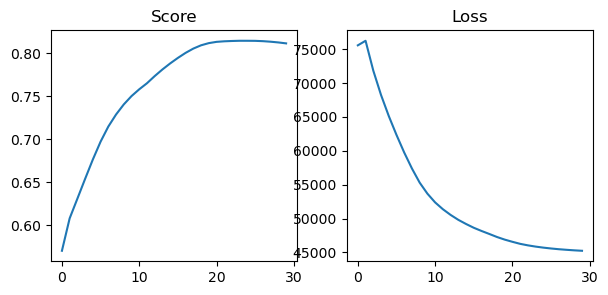

In [18]:
# Results is a list of dictionaries with the following keys "epoch", "loss", "time", "score"
# plot the score of each epoch

fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].plot([r["score"] for r in results2])
ax[0].set_title("Score")
ax[1].plot([r["loss"] for r in results2])
ax[1].set_title("Loss")


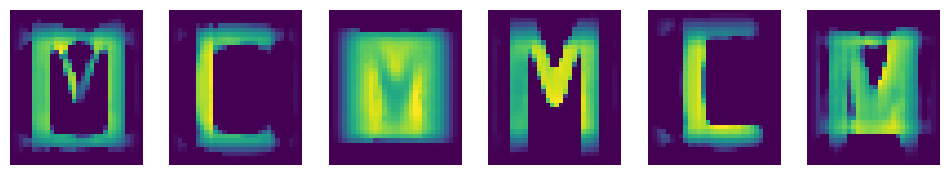

In [19]:
fig, ax = plt.subplots(1, wincdl2.D_hat_.shape[0], figsize=(12, 7))

for i in range(wincdl2.D_hat_.shape[0]):
    ax[i].imshow(wincdl2.D_hat_[i, 0, :, :])
    ax[i].axis("off")

# plt.savefig("results/D_hat_text_AD_during.png")
plt.show()


In [20]:
# Save the D_hat
# np.savez_compressed("results/D_hat_text_AD.npz", D_hat=wincdl2.D_hat_)

In [21]:
np.unique(wincdl2.D_hat_[0, 0, :, :])

array([0.0000000e+00, 2.0423904e-05, 3.2309468e-05, 1.3731061e-04,
       1.4962460e-04, 2.5093392e-04, 2.8363461e-04, 3.0771905e-04,
       3.3715359e-04, 5.8582536e-04, 6.8128313e-04, 1.2223010e-03,
       1.3970190e-03, 1.4137683e-03, 1.7724355e-03, 1.9095922e-03,
       2.0937703e-03, 2.2000719e-03, 2.3760176e-03, 2.5385024e-03,
       2.5458809e-03, 2.6023376e-03, 2.7340250e-03, 2.7385904e-03,
       2.7922480e-03, 2.8803372e-03, 3.1471893e-03, 3.1591277e-03,
       3.2128007e-03, 3.4265441e-03, 3.4304545e-03, 3.4468307e-03,
       3.6089423e-03, 3.6244246e-03, 3.6623001e-03, 3.7824556e-03,
       3.8022078e-03, 3.8890715e-03, 3.9573107e-03, 4.0231477e-03,
       4.1649286e-03, 4.1688867e-03, 4.1697612e-03, 4.2061848e-03,
       4.2361566e-03, 4.2877002e-03, 4.3245833e-03, 4.4320514e-03,
       4.6783756e-03, 4.8666098e-03, 4.9124537e-03, 5.1871017e-03,
       5.7006218e-03, 5.9097921e-03, 5.9138038e-03, 6.0379556e-03,
       6.2328447e-03, 6.5349555e-03, 6.5365471e-03, 6.6155992e

In [ ]:
from wincdl.utils.utils_exp import get_outliers_metric

get_outliers_metric(mask_zoom, wincdl2, X_zooom)

{'accuracy': np.float64(0.9246358024691358),
 'precision': np.float64(0.7788475261898062),
 'recall': np.float64(0.9655625657202944),
 'f1': np.float64(0.8622124111530188),
 'dice': np.float64(0.8622123617258591),
 'jaccard': np.float64(0.7577973424958637),
 'percentage': np.float64(0.3027518518518518)}

In [23]:
xh, zh = wincdl2.csc(torch.tensor(X_zooom).to(wincdl2.device))

In [24]:
xh.shape, zh.shape

(torch.Size([1, 1, 900, 900]), torch.Size([1, 6, 866, 871]))

In [25]:
if isinstance(xh, np.ndarray):
    xh = torch.tensor(xh)
if isinstance(zh, np.ndarray):
    zh = torch.tensor(zh)
if isinstance(X_zooom, np.ndarray):
    X_zooom = torch.tensor(X_zooom)

xh = xh.to(wincdl2.device)
zh = zh.to(wincdl2.device)
X_zooom = X_zooom.to(wincdl2.device)
patch_error = wincdl2.loss_fn.compute_patch_error(xh, zh, X_zooom)

In [26]:
patch_error.shape

torch.Size([1, 1, 900, 900])

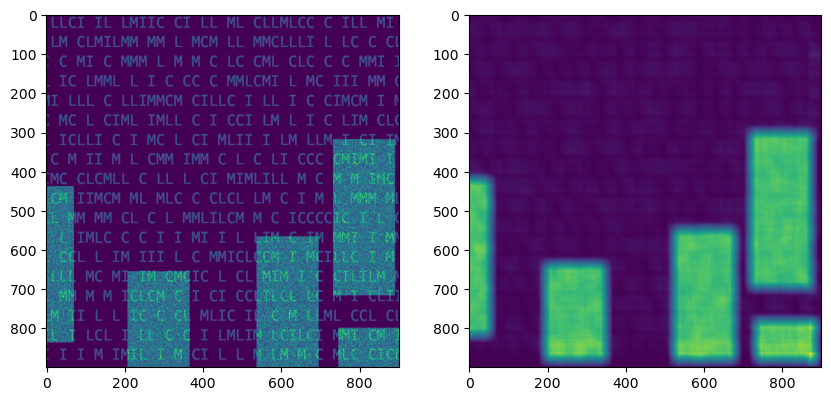

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(X_zooom[0, 0].detach().cpu().numpy())
axes[1].imshow(patch_error[0, 0].detach().cpu().numpy())

In [28]:
model_mask = wincdl2.loss_fn.get_outliers_mask(xh, zh, X_zooom)

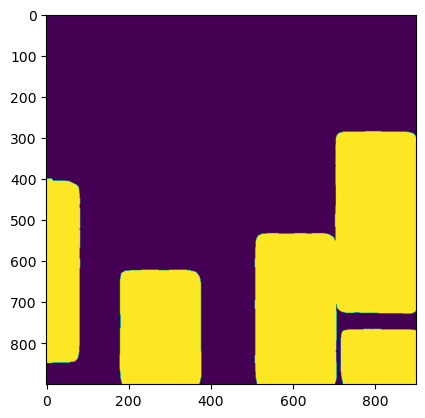

In [29]:
plt.imshow(model_mask[0, 0].detach().cpu().numpy())

In [ ]:
xh = wincdl2.predict(X_zooom)

/storage/store/work/jyehya/WinCDL/wincdl/wincdl.py:262: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, device=self.device, dtype=self.dtype)


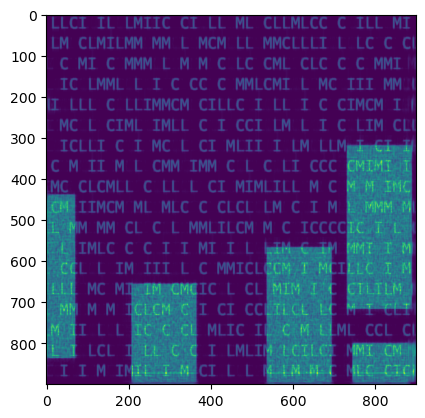

In [31]:
plt.imshow(xh[0, 0])